Building off of Mike's EM notebook, this became a bit of a sprawling testbed for various statistical shenanigans.

In [1]:
#Importing packages
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal
import corner
import scipy.linalg as la

In [2]:
same_dist = False # If true, will ignore choice of mu_2 and set it equal to mu_1
seed = 3221 # Set the seed of the rng

mu1 = 0 # true mean for cluster 1
C1 = 1 # true (co)cariance for cluster 1

mu2 = 5 # true mean for cluster 1
C2 = 1 # true (co)cariance for cluster 1



Nd1 = 200 # Number of samples to draw from the first cluster
Nd2 = 100 # Number of samples to draw from the second cluster

In [3]:
if same_dist:
    mu2 = np.copy(mu1)
    C2 = np.copy(C1)
    
if int(np.__version__[0]) < 2: # Using old numpy
    np.random.seed(seed)
    rng = np.random
else:
    rng = np.random.default_rng(seed=seed)
    
# Make these items compatible with rng.multivariate_normal
mu1 = np.atleast_1d(mu1)
mu2 = np.atleast_1d(mu2)

C1 = np.atleast_2d(C1)
C2 = np.atleast_2d(C2)

In [4]:
def update_pig(ng, n):
    """
    Update the mixture weights for each group based on the current
    number of data assigned to each group and total number of data.
    
    Parameters:
        ng (float, array):
            Number of elements assigned to each group. Is a float because labels are 'soft'
        n (int):
            Total number of data points.
            
    Returns:
        pig (float, array):
            The mixture weights -- may be interpreted in a hierarchical model as the prior
            probability that a data point falls within the respective cluster.
    """
    
    return ng / n

def update_mug(ng, zig, d):
    """
    Update the mean estimate for each cluster based on the current group membership.
    
    Parameters:
        ng (float, array):
            Number of data assigned to each cluster.
        zig (float, array):
            Indicator of cluster membership for each datum i.e. the soft labels.
        d (float, array):
            The data.
        
    Returns:
        mug (float, array):
            The means of the clusters.
    """
    return (d.T @ zig) / ng # Ndim X Ngroup

def update_Sig(ng, zig, mug, d):
    """
    Update the covariance matrices of each cluster.
    
    Parameters:
        ng (float, array):
            Number of data assigned to each cluster.
        zig (float, array):
            Indicator of cluster membership for each datum i.e. the soft labels.
        mug (float, array):
            The means of the clusters.
        d (float, array):
            The data.
    Returns:
        Sig (float, array):
            The covariance matrices for each group (just the variances if data are 1-dimensional)
    """
    res = d[:, None] - mug.T # Nobs X Ngroup X Ndim
    Sig = (zig[:, :, None, None] * (res[:, :, :, None] * res[:, :, None])).sum(axis=0) / ng[:, None, None] # Ngroup X Ndim X Ndim
    return Sig

def update_zig(pig, d, mug, Sig):
    """
    Update the cluster memberships of the data.
    
    Parameters:
        pig (float, array):
            The mixture weights -- may be interpreted in a hierarchical model as the prior
            probability that a data point falls within the respective cluster.
        d (float, array):
            The data.
        mug (float, array):
            The means of the clusters.
        Sig (float, array):
            The covariance matrices for each group (just the variances if data are 1-dimensional)
            
    Returns:
        zig (float, array):
            Indicator of cluster membership for each datum i.e. the soft labels.
    """
    Nobs = d.shape[0]
    Ng = len(pig)
    zig = np.zeros([Nobs, Ng])
    dens = np.zeros([Nobs, Ng])
    for g in range(Ng):
        dens[:, g] = multivariate_normal(mean=mug[:, g], cov=Sig[g]).pdf(d)
    zig_num = pig * dens
    zig_den = zig_num.sum(axis=1)
    
    zig = zig_num / zig_den[:, None]
    ng = zig.sum(axis=0)
    
    return zig, ng

def do_EM(d, zig=None, Niter=int(1e4), Ng=2):
    """
    Do the EM algorithm.
    
    Parameters:
        d (float, array):
            The data.
        zig (None or float_array):
            Initial cluster membership array -- starts somewhere random if set to None (default)
        Niter (int):
            The number of iterations to perform the EM algorithm. 
        Ng (int):
            The number of groups.
    
    Returns:
        pig (float, array):
            Marginal mode of the mixture weights -- may be interpreted in a hierarchical model 
            as the prior probability that a data point falls within the respective cluster.
        mug (float, array):
            Marginal mode for the means of the clusters.
        Sig (float, array):
            Marginal mode for the covariance matrices for each group (just the variances if data are 1-dimensional)
        zig (float, array):
            Conditional expectation of indicator of cluster membership for each datum i.e. the soft labels.
        ng (float, array):
            Number of data assigned to each cluster.
    """
    n = d.shape[0]
    if zig is None:
        zig = rng.dirichlet(np.full(Ng, 1), size=n)
        ng = np.sum(zig, axis=0)
    
    for iter_ind in range(Niter):
        pig = update_pig(ng, n)
        mug = update_mug(ng, zig, d)
        Sig = update_Sig(ng, zig, mug, d)
        zig, ng = update_zig(pig, d, mug, Sig)
    
    return pig, mug, Sig, zig, ng
        
        

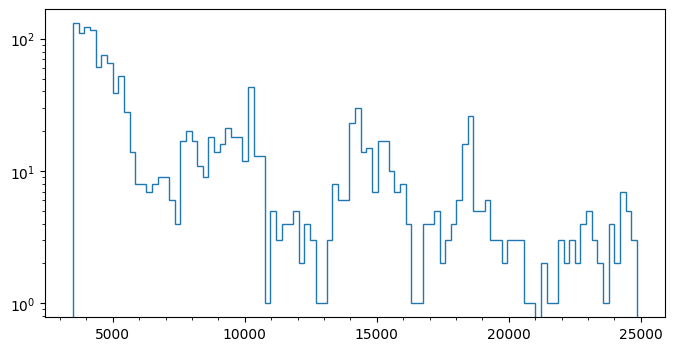

In [5]:
##Some plotting code for INS amplitudes, looking at RFI content per brightness

#Loading amplitudes
amps = np.load("Data/raw_amps_p2.npz")
TV6 = np.sort(amps['arr_0'])
TV7 = np.sort(amps['arr_1'])
TV8 = np.sort(amps['arr_2'])
TV9 = np.sort(amps['arr_3'])

##Plotting
upper = 3000 #some fiducial minimum amplitude
all_TV = np.sort(np.concatenate((TV6,TV7,TV8,TV9)))
outliers = np.sort(all_TV[all_TV > upper])
plt.figure(figsize=(8, 4))
plt.hist(outliers, bins=100, histtype='step', density=False)
plt.yscale('log')
plt.minorticks_on()
plt.show()

In [6]:
pig, mug, Sig, zig, ng = do_EM(np.vstack(outliers), Niter=int(1e4), Ng=5)

In [7]:
print(f"The means for my groups were: {mug}")

The means for my groups were: [[ 4320.08799415  8616.56640229 14575.68402591 18886.60479687
  10194.00446732]]


In [8]:
# Lots of indexing because I've made the code scalable to higher dimensions

print(f"The variances for my groups were: {Sig}")

The variances for my groups were: [[[3.34319126e+05]]

 [[3.16303961e+06]]

 [[4.37938599e+05]]

 [[1.01704838e+07]]

 [[6.54807471e+03]]]


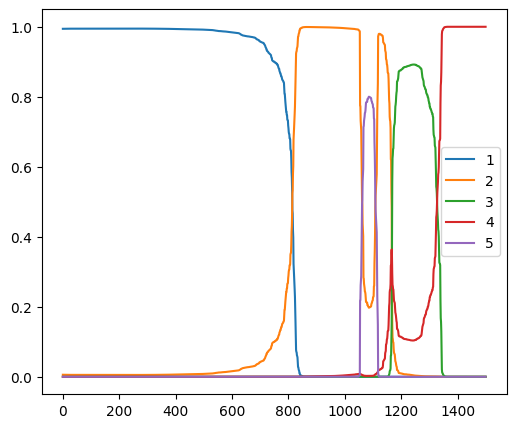

In [9]:
##Plotting Gaussian states (probabilities of where the states are)
plt.figure(figsize=(6, 5))
plt.plot(zig[:, 0], label='1')
plt.plot(zig[:, 1], label='2')
plt.plot(zig[:, 2], label='3')
plt.plot(zig[:, 3], label='4')
plt.plot(zig[:, 4], label='5')
plt.legend()
plt.show()

[ 4320.08799415  8616.56640229 14575.68402591 18886.60479687
 10194.00446732]


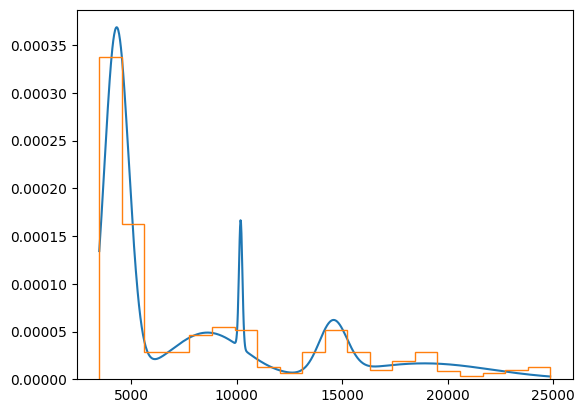

In [10]:
##Plotting mixture model to data
muggy = np.array(mug[0])
print(muggy)

x = np.linspace(np.min(outliers), np.max(outliers), 1000)
gauss = 0 ##Initializing distribution
for i in range(len(muggy)):
    gauss += np.exp(-0.5*((x - muggy[i])**2/(Sig[i][0][0])))/np.sqrt(2*np.pi*Sig[i][0][0])*pig[i]

plt.plot(x, gauss)
plt.hist(outliers, bins='auto', histtype='step', density=True)
plt.yscale('linear')
plt.xlabel('')
plt.show()

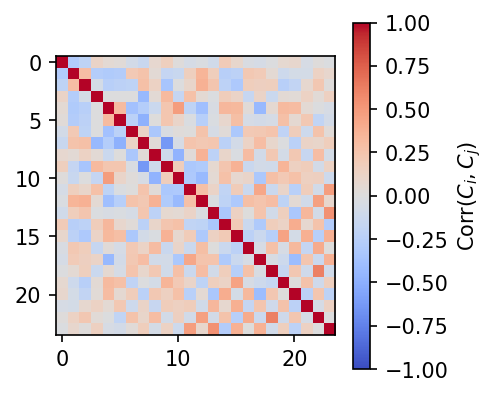

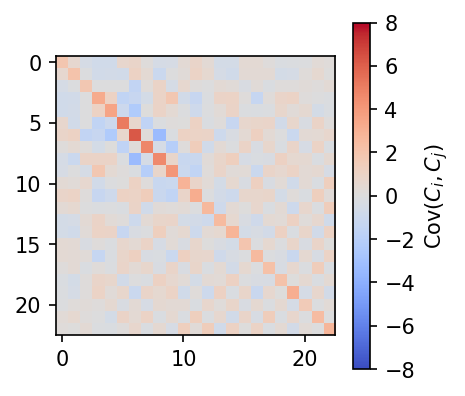

<Figure size 450x450 with 0 Axes>

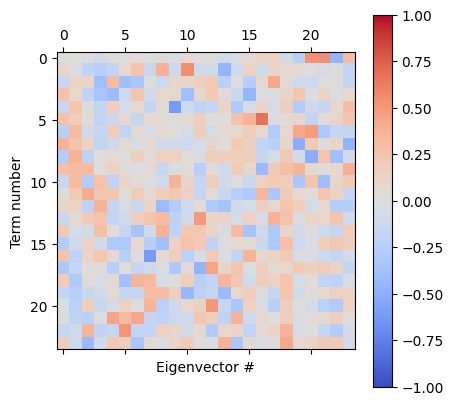

In [11]:
##Looking at the covariances of Legendre coefficients

#Loading in Legendre coefficients
all_coeffs = np.concatenate(
                        (np.load('Data/l_p3_coeffs.npy'),
                         np.load('Data/l_p1_coeffs.npy'),
                         np.load('Data/l_p0_coeffs.npy'),
                         np.load('Data/l_p2_coeffs.npy'),
                        )
)


#Plotting correlation matrix
corr_mat = np.corrcoef(all_coeffs[:, 1:].T)
plt.figure(figsize=(3,3), dpi=150)
plt.imshow(corr_mat[:, :], cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label=r'$\text{Corr}(C_i, C_j)$')
plt.show()

#Plotting covariance matrix
cov_mat = np.cov(all_coeffs[:, 1:].T)
plt.figure(figsize=(3,3), dpi=150)
plt.imshow(cov_mat[1:, 1:], cmap='coolwarm', vmax=8, vmin=-8)
plt.colorbar(label=r'$\text{Cov}(C_i, C_j)$')
plt.show()

#Diagonalizing covariance matrix and looking for principal modes
eivals, eivecs = la.eigh(cov_mat)
plt.figure(figsize=(3,3), dpi=150)
plt.matshow(eivecs, vmin=-1, vmax=1, cmap='coolwarm')
plt.colorbar()
plt.xlabel("Eigenvector #")
plt.ylabel("Term number")
plt.show()

(25, 3)


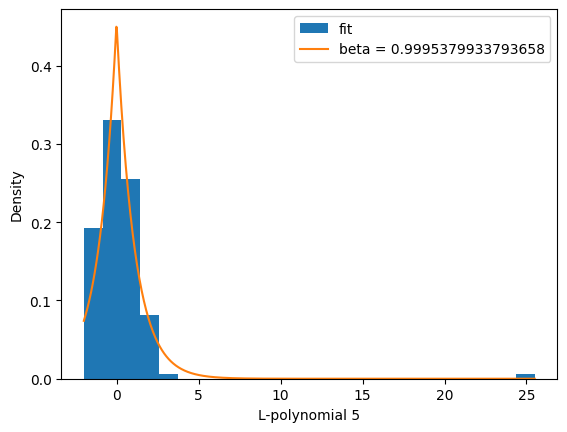

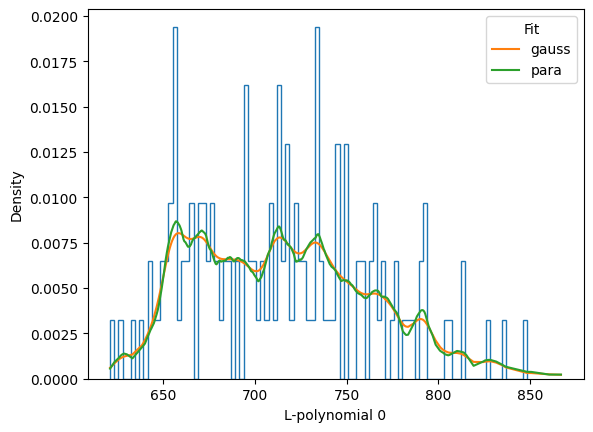

(544,)


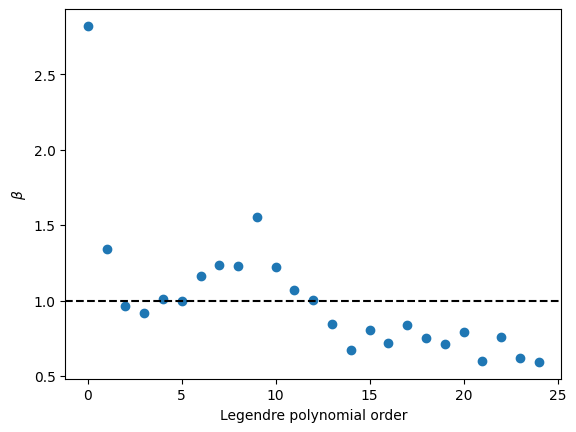

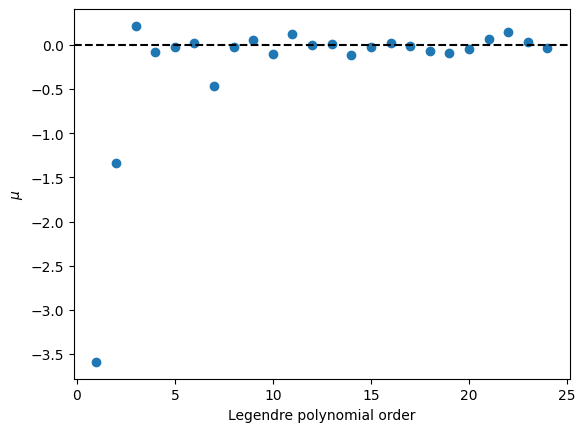

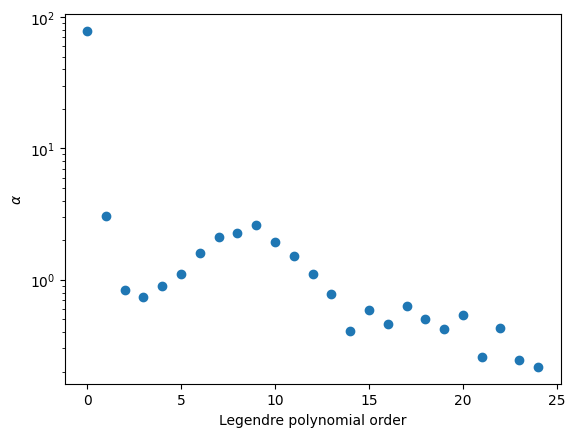

In [12]:
##Plotting and breaking down coefficient statistics further

#Importing gennorm package
from scipy.stats import gennorm

#Fitting gennorm distributions for Legendre coefficients
params = gennorm.fit(all_coeffs[:, 0])
beta, loc, scale = params
coeff_params = np.array([beta, loc, scale])

for i in range(1, all_coeffs.shape[1]):
    params = gennorm.fit(all_coeffs[:, i])
    beta, loc, scale = params
    coeff_params = np.vstack((coeff_params, np.array([beta, loc, scale])))
cnum = 5 #L-polynomial order


coeffs = np.load('Data/l_p3_coeffs.npy')
print(coeff_params.shape)
x = np.linspace(coeffs[:, cnum].min(), coeffs[:, cnum].max(), 1000)
plt.hist(coeffs[:, cnum], bins='auto', density=True, label='fit')
plt.plot(x, gennorm.pdf(x, *coeff_params[cnum, :]), label=f'beta = {coeff_params[cnum, 0]}')
plt.xlabel(f'L-polynomial {cnum}')
plt.ylabel('Density')
#plt.yscale('log')
plt.legend()
plt.show()


#Defining Gaussian and parabolic kernels for KDE
def gauss_kern(data, smooth=0.1):
    fit_func = 0

    for x in data:
        fit_func += np.exp(-0.5*((data - x)/(np.std(data)*smooth))**2)
    
    return fit_func/np.trapezoid(fit_func, data)

def para_kern(data, smooth=1):
    fit_func = 0

    for x in data:
        fit_func += np.where(-(data - x)**2/np.std(data)/smooth + 1 > 0,
                             -(data - x)**2/np.std(data)/smooth + 1, 0)
    
    return fit_func/np.trapezoid(fit_func, data)


#Looking at the behaviour of L_0, the constant term
x = np.linspace(all_coeffs[:, cnum].min(), all_coeffs[:, cnum].max(), 1000)
plt.hist(all_coeffs[2::4, 0], bins=100, density=True, histtype='step')
plt.plot(np.sort(all_coeffs[:, 0]), gauss_kern(np.sort(all_coeffs[:, 0])), label='gauss')
plt.plot(np.sort(all_coeffs[:, 0]), para_kern(np.sort(all_coeffs[:, 0])), label='para')
#plt.plot(x, gennorm.pdf(x, *coeff_params[0, :]), label=f'beta = {coeff_params[0, 0]}')
plt.legend(title="Fit")
plt.xlabel(f'L-polynomial {0}')
plt.ylabel('Density')
#plt.yscale('log')
plt.show()

print(all_coeffs[:, 0].shape)

plt.scatter(np.arange(0, 25), coeff_params[:, 0])
plt.xlabel("Legendre polynomial order")
plt.ylabel(r"$\beta$")
plt.axhline(y=1, color='k', linestyle='--')
plt.show()

plt.scatter(np.arange(1, 25), coeff_params[1:, 1])
plt.xlabel("Legendre polynomial order")
plt.ylabel(r"$\mu$")
plt.axhline(y=0, color='k', linestyle='--')
plt.show()

plt.scatter(np.arange(0, 25), coeff_params[:, 2])
plt.xlabel("Legendre polynomial order")
plt.ylabel(r"$\alpha$")
plt.axhline(y=0, color='k', linestyle='--')
plt.yscale('log')
plt.show()

(544, 25)


<Figure size 3000x3000 with 0 Axes>

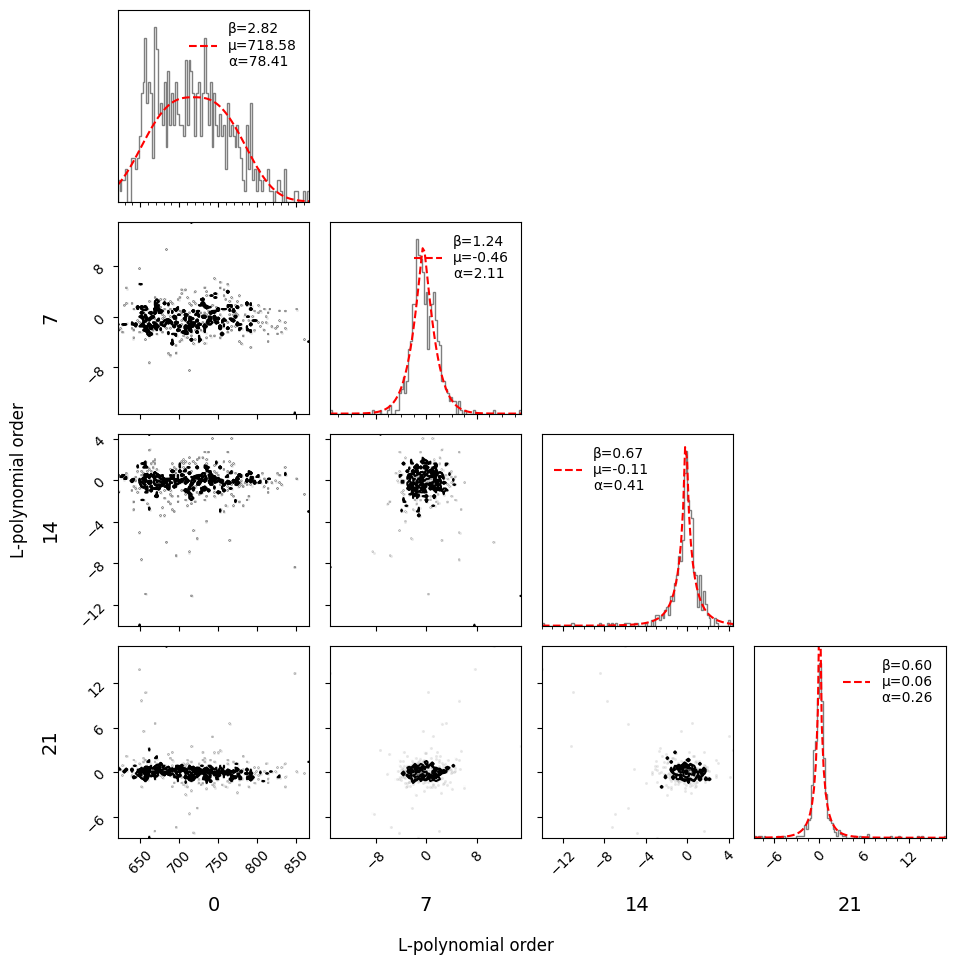

<Figure size 640x480 with 0 Axes>

In [13]:
##Nice plot of coefficients

coeffs = np.concatenate(
                        (np.load('Data/l_p3_coeffs.npy'),
                         np.load('Data/l_p1_coeffs.npy'),
                         np.load('Data/l_p0_coeffs.npy'),
                         np.load('Data/l_p2_coeffs.npy'),
                        )
)

print(coeffs.shape)


plt.figure(dpi=1000, figsize=(3, 3))
labels = np.arange(0, coeffs[:, :].shape[1]+1)[0::7]

figure = corner.corner(coeffs[:, 0::7], labels=labels, bins=100,
                      hist_kwargs={'density': True, 'alpha': 0.5},
                      label_kwargs={'fontsize': 14},
                      title_kwargs={'fontsize': 14})

ndim = coeffs[:, 0::7].shape[1]


# Simple version - just add x² to each marginal
for i in range(ndim):
    ax_idx = i * (ndim + 1)
    ax = figure.axes[ax_idx]
    x = np.linspace(*ax.get_xlim(), 100)
    dist_param = coeff_params[0::7, :][i]
    ax.plot(x, gennorm.pdf(x, *coeff_params[0::7, :][i]), linestyle='--', color='red', label=f'β={dist_param[0]:.2f}\nμ={dist_param[1]:.2f}\nα={dist_param[2]:.2f}')
    ax.minorticks_on()
    ax.legend(fontsize=10, frameon=False)


figure.supxlabel(r"L-polynomial order")
figure.supylabel(r"L-polynomial order")
figure.set_tight_layout('tight')

plt.show()

# Convert diagonal plots to semilog scale
ndim = coeffs[:, 0::7].shape[1]  # Number of dimensions

# Get the axes from the corner plot
axes = np.array(figure.axes).reshape((ndim, ndim))

# Modify only the diagonal plots (marginals)
for i in range(ndim):

    ax = axes[i, i]  # Diagonal axis

    
    # Clear the current histogram
    ax.clear()
    
    # Get the data for this dimension
    data = coeffs[:, i]
    x = np.linspace(data.min(), data.max(), 1000)
    ax.plot(x, np.log(gennorm.pdf(x, *coeff_params[i, :])))
    
    # Replot with semilog scale
    counts, bins, patches = ax.hist(data, bins=100, alpha=0.7, color='white', edgecolor='black', density=True)
    
    # Set y-axis to logarithmic scale
    ax.set_yscale('log')
    
    # Remove negative values from log scale if they exist
    if np.any(counts <= 0):
        # Add a small offset to avoid log(0)
        counts = np.maximum(counts, 1e-10)
        ax.clear()
        ax.hist(data, bins=100, alpha=0.7, color='white', edgecolor='black')
        ax.set_yscale('log')
    
plt.tight_layout()
plt.show()

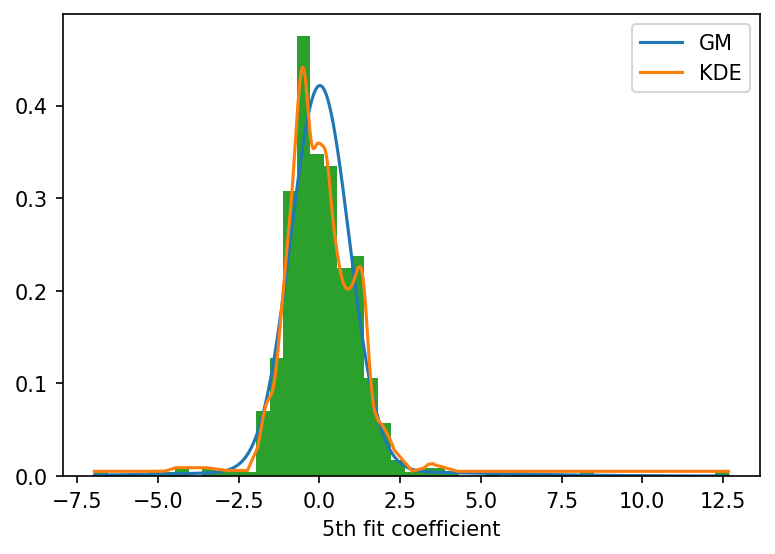

In [14]:
#Comparing gaussian mixture vs KDE estimate

term = 5

pig1, mug1, Sig1, zig1, ng1 = do_EM(np.vstack(coeffs.T[term-1]), Niter=int(1e4), Ng=2)

muggy = mug1[0]
x = np.linspace(np.min(coeffs.T[term-1]), np.max(coeffs.T[term-1]), 1000)
gauss = 0
for i in range(len(muggy)):
    gauss += np.exp(-0.5*((x - muggy[i])**2/(Sig1[i][0][0])))/np.sqrt(2*np.pi*Sig1[i][0][0])*pig1[i]

plt.figure(figsize=(6,4), dpi=150)
plt.plot(x, gauss, label='GM')
plt.plot(np.sort(coeffs.T[term-1]), gauss_kern(np.sort(coeffs.T[term-1])), label='KDE')
plt.legend()
plt.hist(coeffs.T[term-1], bins='auto', density=True)
plt.xlabel(f'{term}th fit coefficient')
plt.yscale('linear')
plt.show()

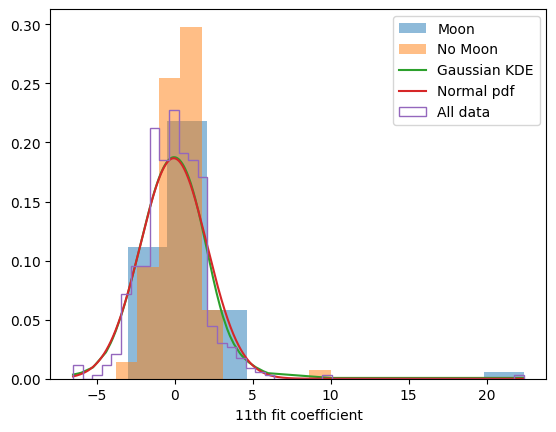

In [15]:
#Looking at the moon and how the coefficients roughly look between different positions of the moon over season

term=11

moon_coeffs = np.concatenate((coeffs.T[term-1][500:600], coeffs.T[term-1][:30]))
plt.hist(moon_coeffs, density=True, alpha=0.5, label='Moon')
plt.hist(coeffs.T[term-1][200:300], density=True, alpha=0.5, label='No Moon')


x = np.linspace(np.min(coeffs.T[term - 1]), np.max(coeffs.T[term-1]), 1000)
plt.plot(np.sort(coeffs.T[term-1]), gauss_kern(np.sort(coeffs.T[term-1]), smooth=0.5), label='Gaussian KDE')
plt.plot(x, np.exp(-(x-np.mean(coeffs.T[term-1]))**2/(2*np.std(coeffs.T[term-1])**2))/np.sqrt(2*np.pi*np.std(coeffs.T[term-1])**2), label='Normal pdf')
plt.hist(coeffs.T[term-1], bins='auto', density=True, histtype='step', label='All data')
plt.legend()
plt.yscale('linear')
plt.xlabel('11th fit coefficient')
plt.ylabel('')
plt.show()

32706


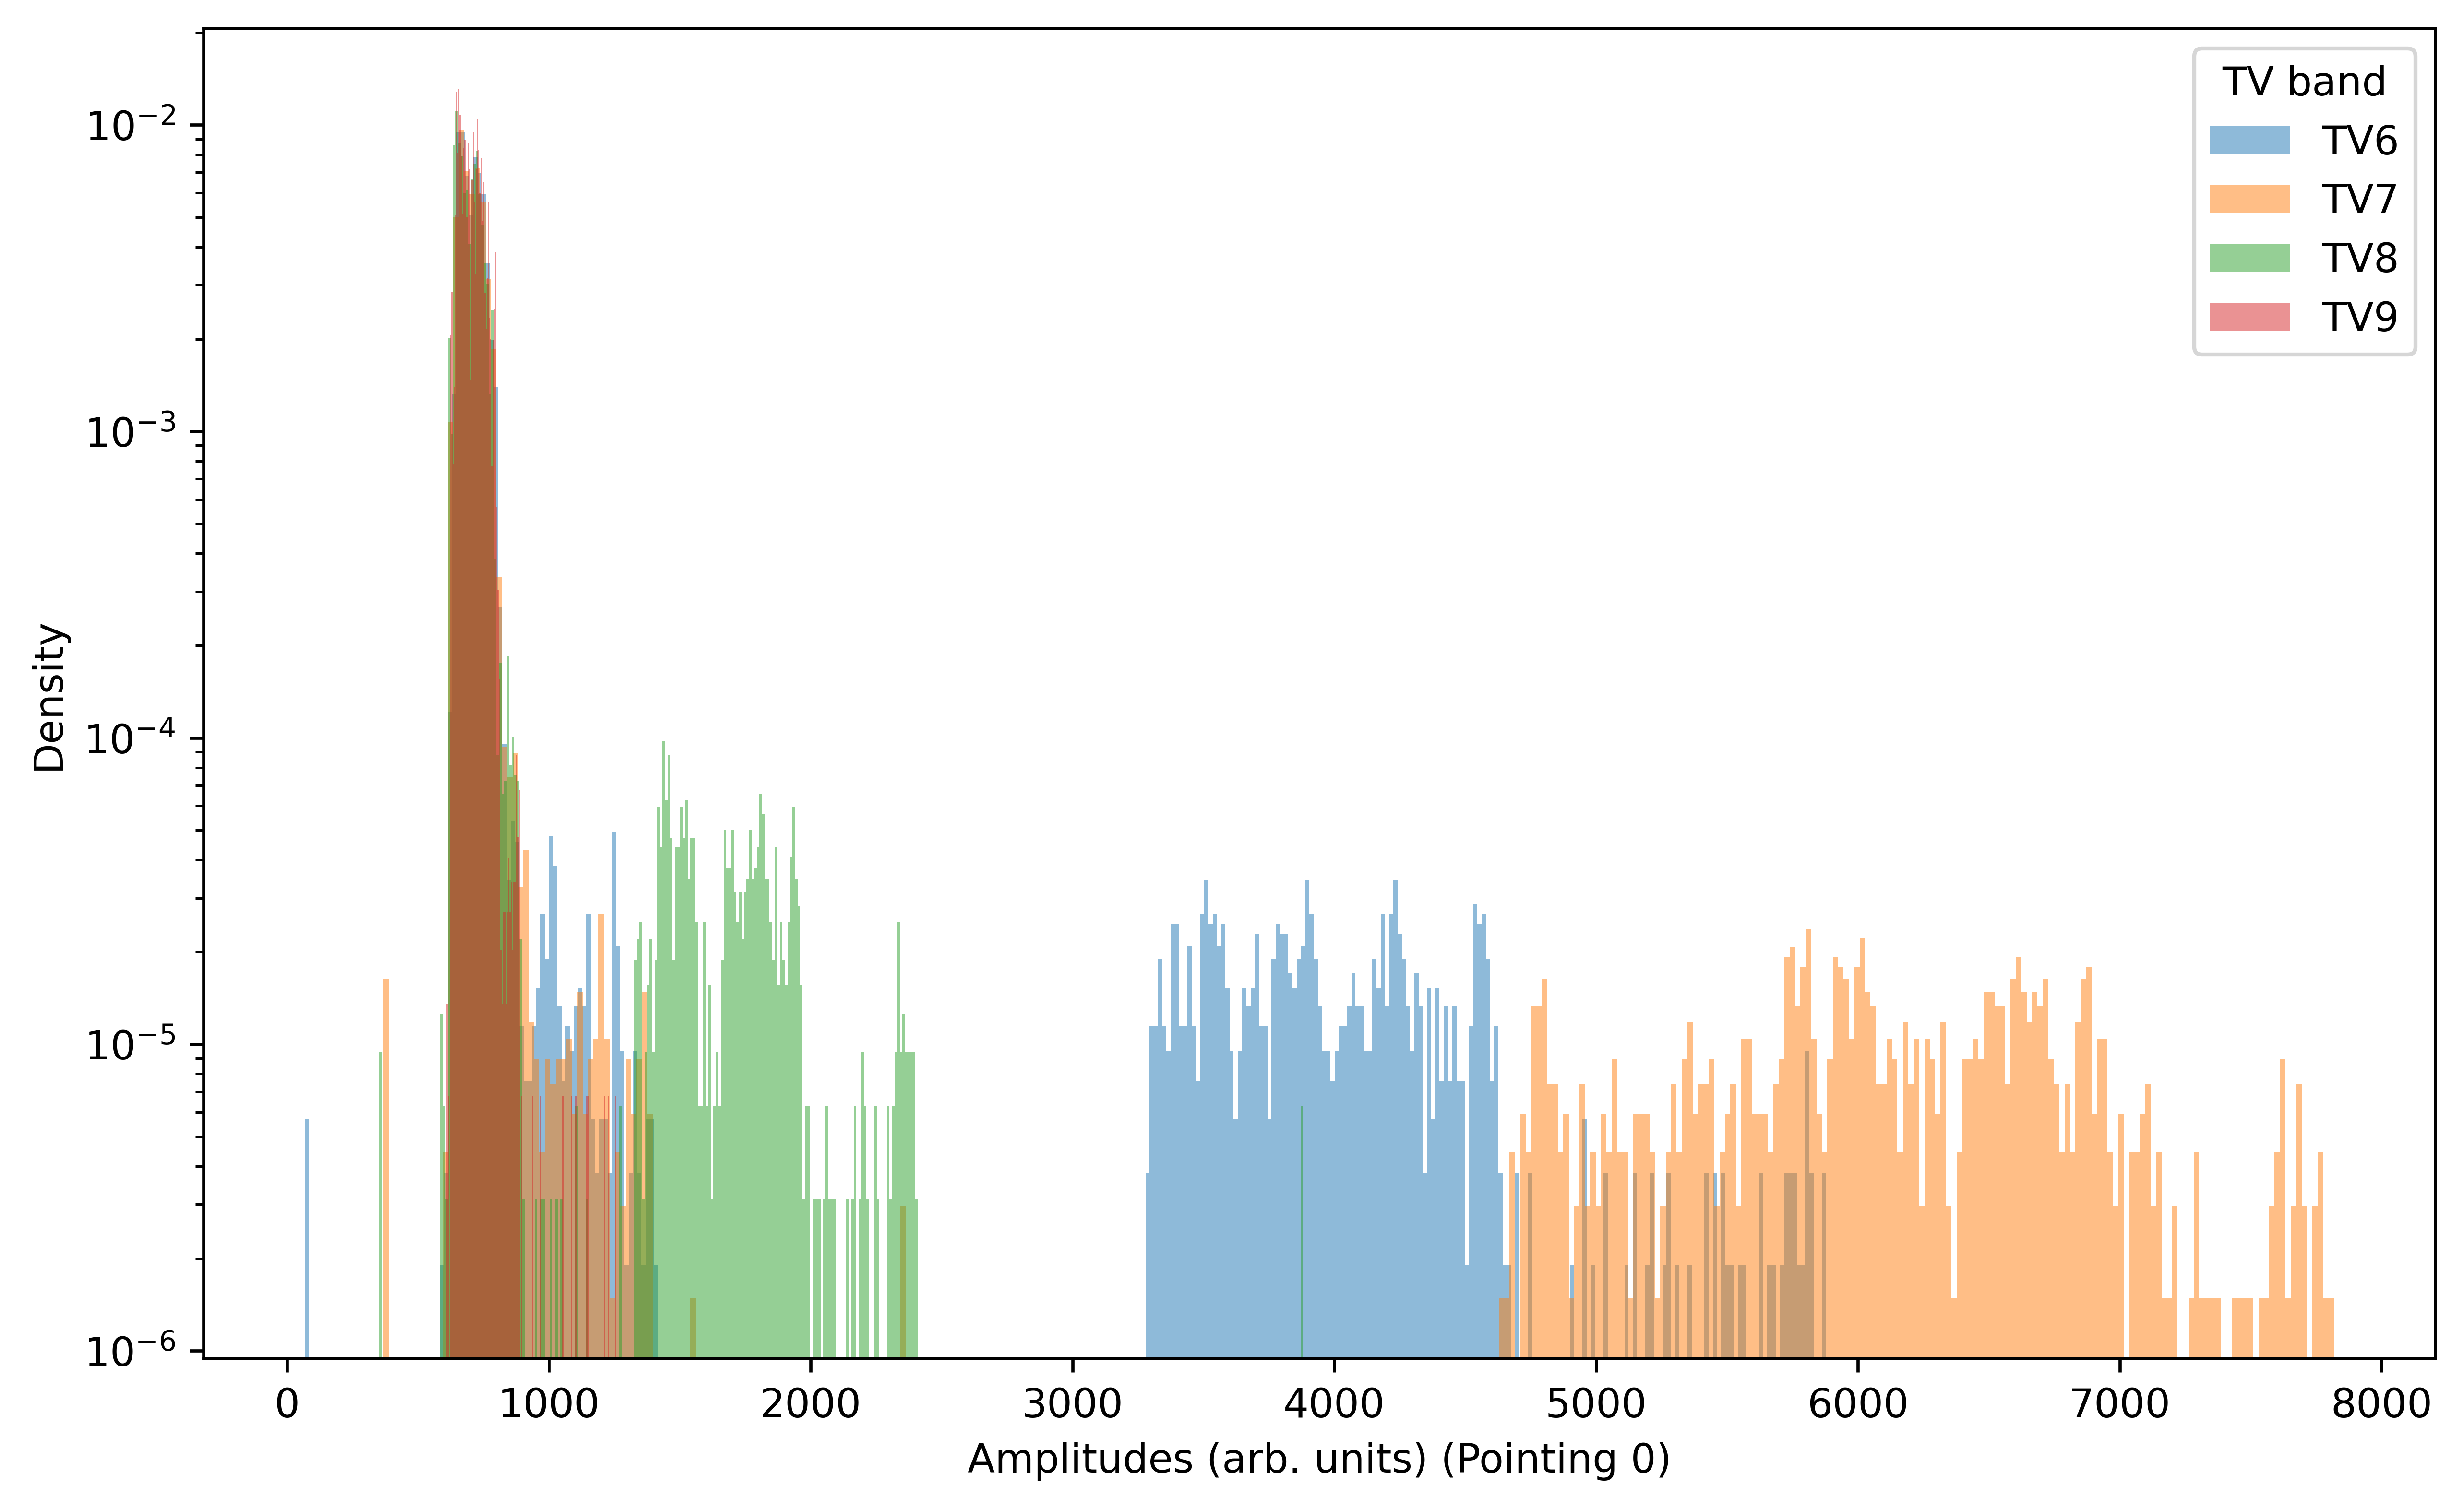

In [16]:
# Raw INS amplitudes per pointing over TV band

import json

point = '0'

with open(f'Data/p{point}_amps.json', 'r') as f:
    p_amps = json.load(f)



all_amps = np.concatenate(list(p_amps.values()))
TV6_amps = np.concatenate(list({k: v for k, v in p_amps.items() if 'TV6' in k}.values()))
TV7_amps = np.concatenate(list({k: v for k, v in p_amps.items() if 'TV7' in k}.values()))
TV8_amps = np.concatenate(list({k: v for k, v in p_amps.items() if 'TV8' in k}.values()))
TV9_amps = np.concatenate(list({k: v for k, v in p_amps.items() if 'TV9' in k}.values()))


cutoff=0

plt.figure(figsize=(10, 6), dpi=600)
plt.hist(TV6_amps[TV6_amps>cutoff], bins='auto', histtype='bar', label='TV6', alpha=0.5, density=True)
plt.hist(TV7_amps[TV7_amps>cutoff], bins='auto', histtype='bar', label='TV7', alpha=0.5, density=True)
plt.hist(TV8_amps[TV8_amps>cutoff], bins='auto', histtype='bar', label='TV8', alpha=0.5, density=True)
plt.hist(TV9_amps[TV9_amps>cutoff], bins='auto', histtype='bar', label='TV9', alpha=0.5, density=True)
#plt.hist(all_amps[all_amps>cutoff], bins='auto', histtype='step', label='All', color='black', alpha=0.5, linestyle='--', density=True)

#plt.plot(np.sort(TV7_amps[TV7_amps > cutoff]), gauss_kern(np.sort(TV7_amps[TV7_amps > cutoff])))
#plt.plot(np.sort(TV6_amps[TV6_amps > cutoff]), gauss_kern(np.sort(TV6_amps[TV6_amps > cutoff])))

print(TV7_amps[TV7_amps > cutoff].shape[0])

plt.legend(title='TV band')
plt.yscale('log')
plt.xscale('linear')
plt.xlabel(f'Amplitudes (arb. units) (Pointing {point})')
plt.ylabel('Density')
plt.show()

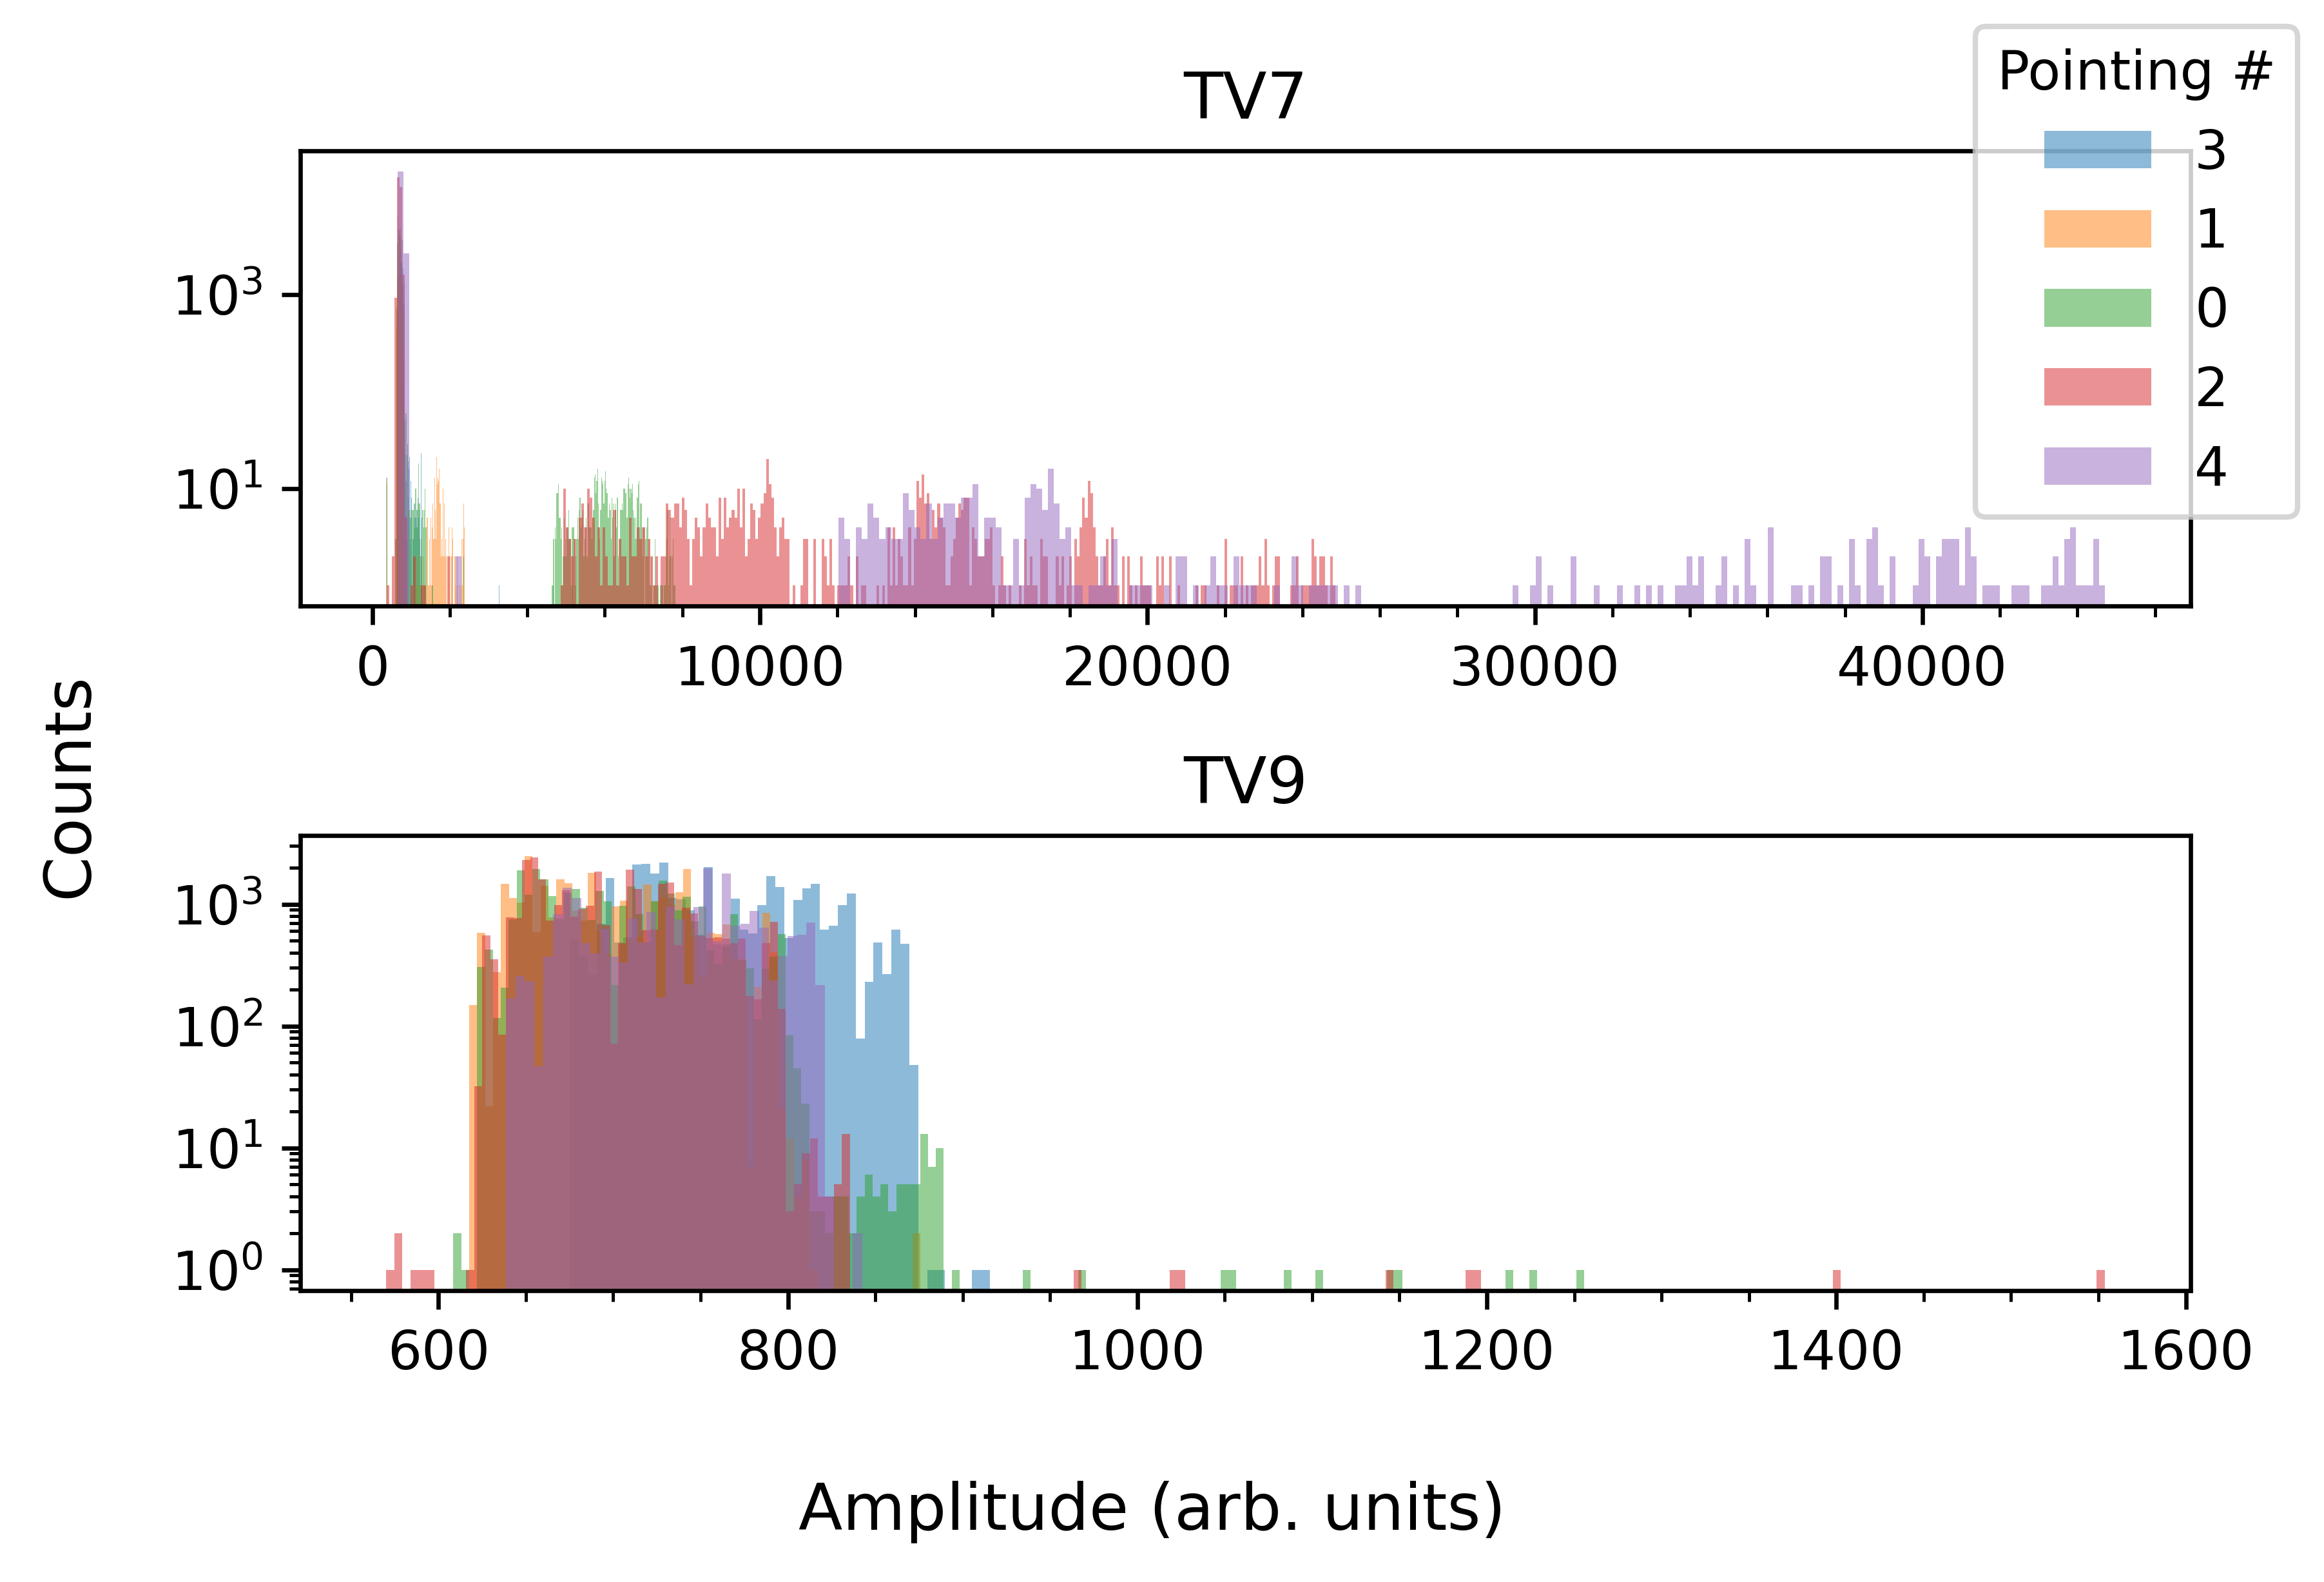

In [17]:
##Plotting amplitudes per TV band over points

with open('Data/p0_amps.json', 'r') as f:
    p0_amps_open = json.load(f)

with open('Data/p1_amps.json', 'r') as f:
    p1_amps_open = json.load(f)

with open('Data/p2_amps.json', 'r') as f:
    p2_amps_open = json.load(f)

with open('Data/p3_amps.json', 'r') as f:
    p3_amps_open = json.load(f)

with open('Data/p4_amps.json', 'r') as f:
    p4_amps_open = json.load(f)

tv_chan = 'TV7'
p0_amps = np.concatenate(list({k: v for k, v in p0_amps_open.items() if tv_chan in k}.values()))
p1_amps = np.concatenate(list({k: v for k, v in p1_amps_open.items() if tv_chan in k}.values()))
p2_amps = np.concatenate(list({k: v for k, v in p2_amps_open.items() if tv_chan in k}.values()))
p3_amps = np.concatenate(list({k: v for k, v in p3_amps_open.items() if tv_chan in k}.values()))
p4_amps = np.concatenate(list({k: v for k, v in p4_amps_open.items() if tv_chan in k}.values()))

fig, ax = plt.subplots(figsize=(6, 4), dpi=600, nrows=2)


ax[0].hist(p3_amps, histtype='bar', bins='auto', alpha=0.5, label='3', density=False)
ax[0].hist(p1_amps, histtype='bar', bins='auto', alpha=0.5, label='1', density=False)
ax[0].hist(p0_amps, histtype='bar', bins='auto', alpha=0.5, label='0', density=False)
ax[0].hist(p2_amps, histtype='bar', bins='auto', alpha=0.5, label='2', density=False)
ax[0].hist(p4_amps, histtype='bar', bins='auto', alpha=0.5, label='4', density=False)
ax[0].set_title(tv_chan)


tv_chan = 'TV9'
p0_amps = np.concatenate(list({k: v for k, v in p0_amps_open.items() if tv_chan in k}.values()))
p1_amps = np.concatenate(list({k: v for k, v in p1_amps_open.items() if tv_chan in k}.values()))
p2_amps = np.concatenate(list({k: v for k, v in p2_amps_open.items() if tv_chan in k}.values()))
p3_amps = np.concatenate(list({k: v for k, v in p3_amps_open.items() if tv_chan in k}.values()))
p4_amps = np.concatenate(list({k: v for k, v in p4_amps_open.items() if tv_chan in k}.values()))

ax[1].hist(p3_amps, histtype='bar', bins='auto', alpha=0.5, density=False)
ax[1].hist(p1_amps, histtype='bar', bins='auto', alpha=0.5, density=False)
ax[1].hist(p0_amps, histtype='bar', bins='auto', alpha=0.5, density=False)
ax[1].hist(p2_amps, histtype='bar', bins='auto', alpha=0.5, density=False)
ax[1].hist(p4_amps, histtype='bar', bins='auto', alpha=0.5, density=False)
ax[1].set_title(tv_chan)
#plt.hist(np.concatenate((p3_amps, p1_amps, p0_amps, p2_amps, p4_amps)), histtype='bar', bins='auto', alpha=0.5, density=False)
fig.legend(title='Pointing #')
fig.supxlabel(f'Amplitude (arb. units)')
fig.supylabel('Counts')
ax[0].set_yscale('log')
ax[1].set_yscale('log')
#plt.xscale('log')
ax[0].minorticks_on()
ax[1].minorticks_on()
fig.set_tight_layout('tight')
plt.show()